
Verarbeite: Teil2_Messung 1.dat
Datenpunkte: 851
p_inf = 1215.23 ± 0.22 mbar
k = 1.3900e-03 1/s


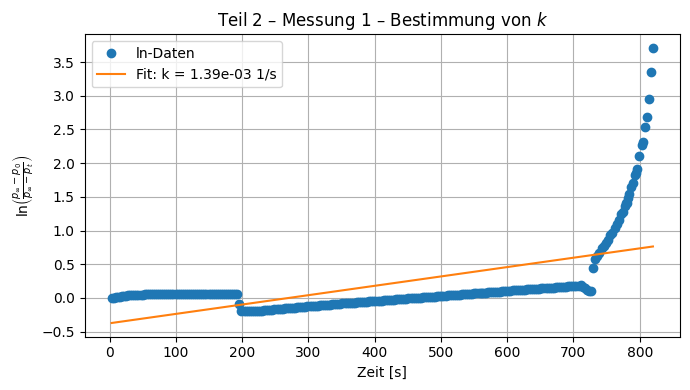

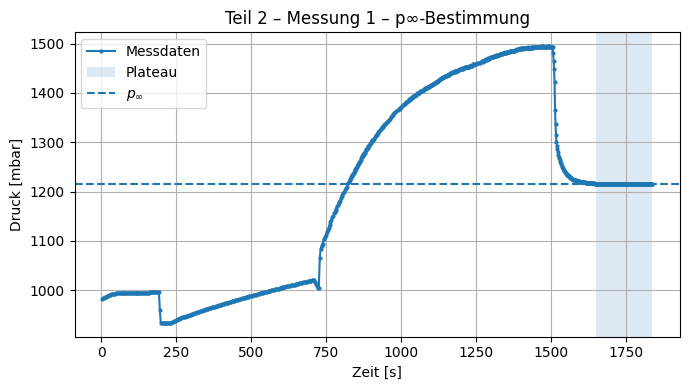

k-Fit-Zeitbereich: 3.0 s bis 819.9 s

Verarbeite: Teil 2_Messung 2.dat
Datenpunkte: 1099
p_inf = 1176.44 ± 0.95 mbar
k = 1.6359e-03 1/s


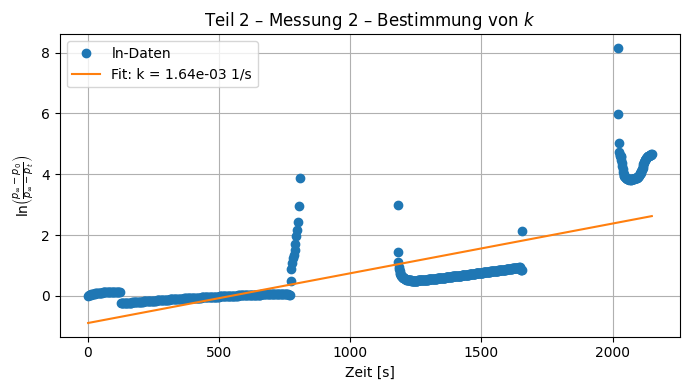

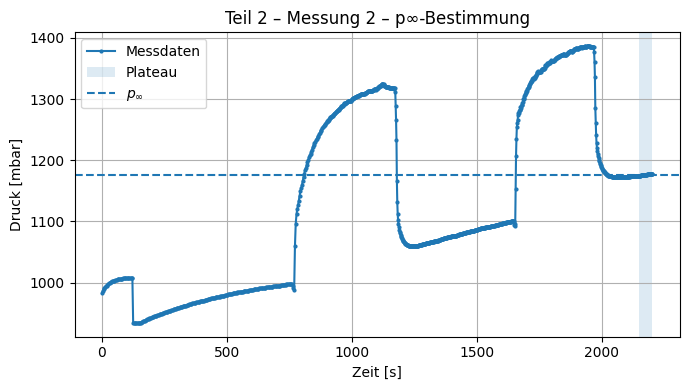

k-Fit-Zeitbereich: 1.5 s bis 2149.6 s

Verarbeite: Teil 2_Messung 3.dat
Datenpunkte: 542
p_inf = 1214.18 ± 0.68 mbar
k = 2.0013e-03 1/s


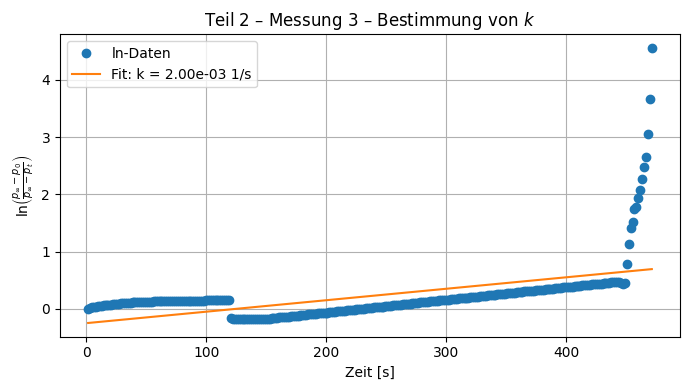

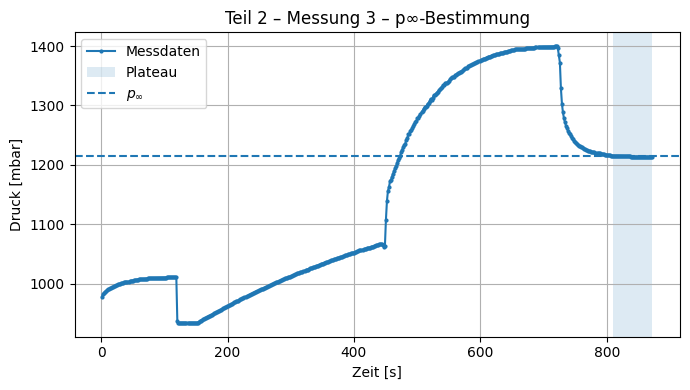

k-Fit-Zeitbereich: 1.5 s bis 471.5 s


In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Konfiguration
# =========================================================
cfg = {
 "Teil2_Messung 1.dat": {"plateau_start": 1650, "title": "Teil 2 – Messung 1"},
 "Teil 2_Messung 2.dat": {"plateau_start": 2150, "title": "Teil 2 – Messung 2"},
 "Teil 2_Messung 3.dat": {"plateau_start": 810,  "title": "Teil 2 – Messung 3"},
}

# =========================================================
# Schleife über die Messungen
# =========================================================
for fname, c in cfg.items():
 print("\n" + "="*60)
 print("Verarbeite:", fname)

 # -----------------------------
 # 1) Datei laden
 # -----------------------------
 df = pd.read_csv(
     fname,
     sep=r"\s+",
     decimal=",",
     header=None,
     names=["Zeit", "Druck"],
     engine="python"
 ).dropna()

 print(f"Datenpunkte: {len(df)}")

 # -----------------------------
 # 2) Plateau-Bereich
 # -----------------------------
 t_plateau_start = c["plateau_start"]
 df_plateau = df[df["Zeit"] >= t_plateau_start]

 if df_plateau.empty:
     raise ValueError(f"❌ Plateau leer in {fname}")

 p_inf = df_plateau["Druck"].mean()
 p_inf_std = df_plateau["Druck"].std()

 print(f"p_inf = {p_inf:.2f} ± {p_inf_std:.2f} mbar")

 # -----------------------------
 # 3) k-Bestimmung über ln-Plot
 # -----------------------------
 p0 = df["Druck"].iloc[0]

 df_lin = df[df["Zeit"] < t_plateau_start].copy()
 df_lin = df_lin[df_lin["Druck"] < p_inf]

 df_lin["ln_term"] = np.log((p_inf - p0) / (p_inf - df_lin["Druck"]))

 # Fit-Bereich (hier ggf. einschränken!)
 t_fit_min = df_lin["Zeit"].min()
 t_fit_max = df_lin["Zeit"].max()

 df_fit = df_lin[
     (df_lin["Zeit"] >= t_fit_min) &
     (df_lin["Zeit"] <= t_fit_max)
 ]

 if df_fit.empty:
     raise ValueError("❌ Kein linearer Bereich für k")

 k, b = np.polyfit(df_fit["Zeit"], df_fit["ln_term"], 1)
 print(f"k = {k:.4e} 1/s")

 # -----------------------------
 # 4) ln-Plot (k-Bestimmung)
 # -----------------------------
 plt.figure(figsize=(7,4))
 plt.plot(df_fit["Zeit"], df_fit["ln_term"], "o", label="ln-Daten")
 plt.plot(
     df_fit["Zeit"],
     k * df_fit["Zeit"] + b,
     "-",
     label=f"Fit: k = {k:.2e} 1/s"
 )
 plt.xlabel("Zeit [s]")
 plt.ylabel(r"$\ln\!\left(\frac{p_\infty-p_0}{p_\infty-p_t}\right)$")
 plt.title(c["title"] + " – Bestimmung von $k$")
 plt.grid(True)
 plt.legend()
 plt.tight_layout()
 plt.show()

 # -----------------------------
 # 5) Messdaten + Plateau
 # -----------------------------
 plt.figure(figsize=(7,4))
 plt.plot(df["Zeit"], df["Druck"], "o-", markersize=2, label="Messdaten")
 plt.axvspan(t_plateau_start, df["Zeit"].max(), alpha=0.15, label="Plateau")
 plt.axhline(p_inf, linestyle="--", label=r"$p_\infty$")
 plt.xlabel("Zeit [s]")
 plt.ylabel("Druck [mbar]")
 plt.title(c["title"] + " – p∞-Bestimmung")
 plt.grid(True)
 plt.legend()
 plt.tight_layout()
 plt.show()

 print(f"k-Fit-Zeitbereich: {df_fit['Zeit'].min():.1f} s bis {df_fit['Zeit'].max():.1f} s")

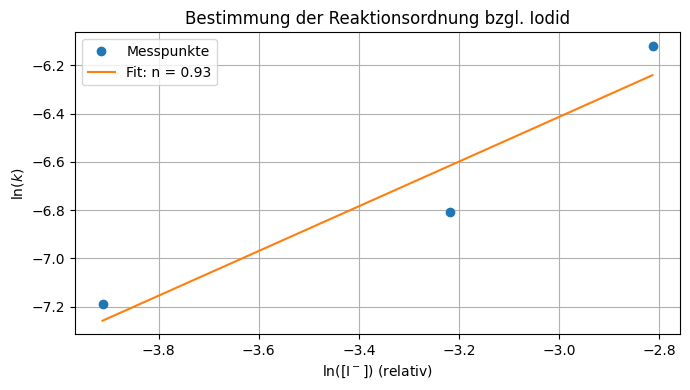

Reaktionsordnung n (bzgl. I-) = 0.927
y = [-7.18794549 -6.80754802 -6.11943429]


In [74]:
import numpy as np
import matplotlib.pyplot as plt

# Proxy für [I-] (z.B. V_KI in mL oder 1,2,3)
I_rel = np.array([0.02, 0.04, 0.06], dtype=float)

k = np.array([7.5564e-04, 1.1054e-03, 2.1997e-03], dtype=float)

x = np.log(I_rel)
y = np.log(k)

# linearer Fit: y = n*x + b
n, b = np.polyfit(x, y, 1)

plt.figure(figsize=(7,4))
plt.plot(x, y, "o", label="Messpunkte")
plt.plot(x, n*x + b, "-", label=f"Fit: n = {n:.2f}")
plt.xlabel(r"$\ln([\mathrm{I^-}])$ (relativ)")
plt.ylabel(r"$\ln(k)$")
plt.title("Bestimmung der Reaktionsordnung bzgl. Iodid")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Reaktionsordnung n (bzgl. I-) = {n:.3f}")
print("y =", y)


Verarbeite: Teil2_Messung 1.dat
p_inf = 1215.23 mbar
k = 7.5564e-04 1/s  (Fitbereich 270–700 s)


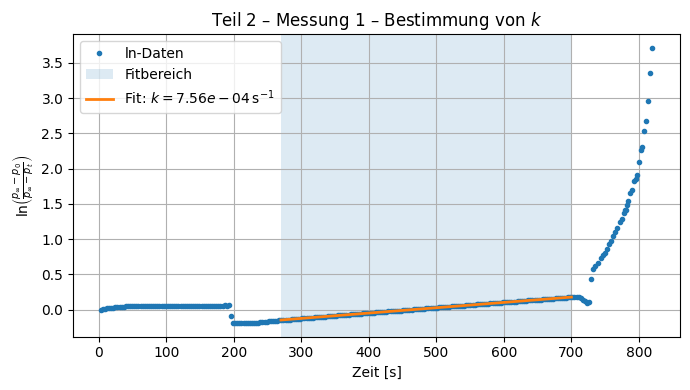

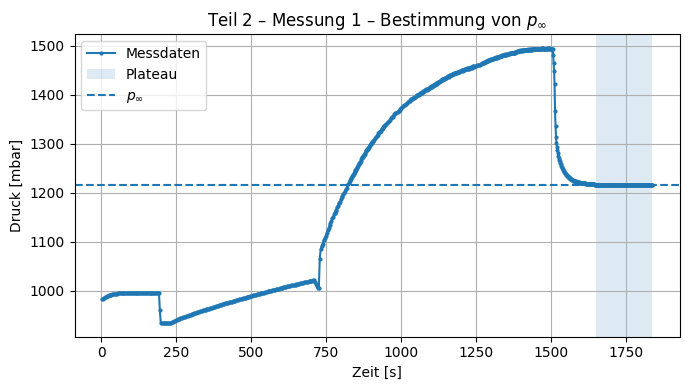


Verarbeite: Teil 2_Messung 2.dat
p_inf = 1176.44 mbar
k = 1.1054e-03 1/s  (Fitbereich 1250–1600 s)


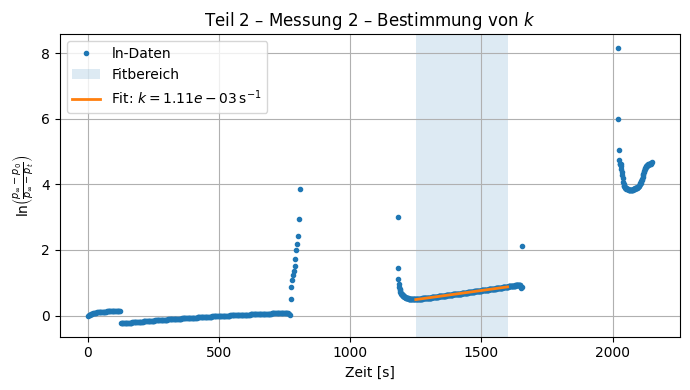

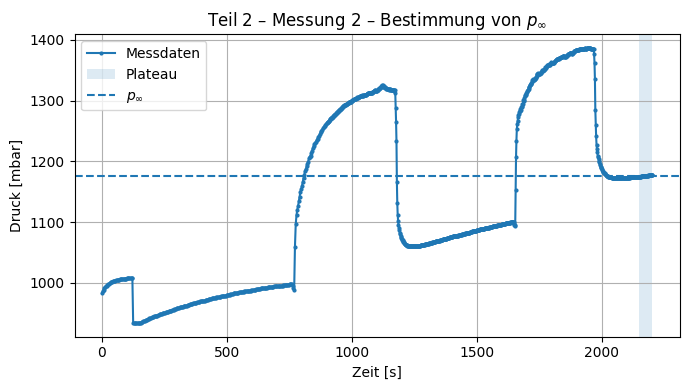


Verarbeite: Teil 2_Messung 3.dat
p_inf = 1214.18 mbar
k = 2.1997e-03 1/s  (Fitbereich 170–450 s)


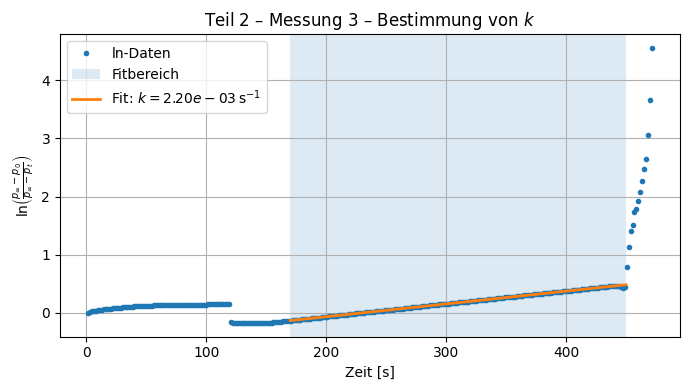

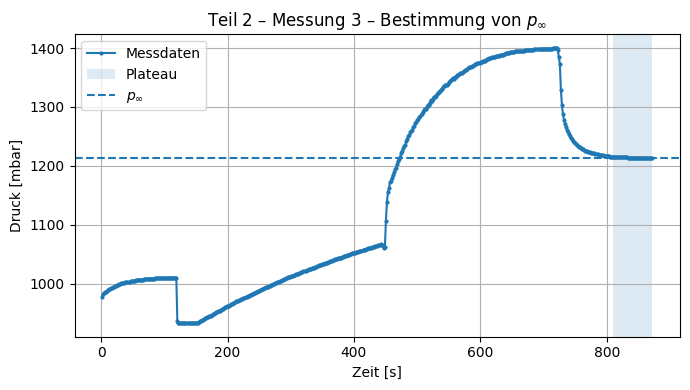

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Konfiguration: Plateau + k-Fitbereich pro Messung
# =========================================================
cfg = {
    "Teil2_Messung 1.dat": {
        "plateau_start": 1650,
        "k_fit_min": 270,
        "k_fit_max": 700,
        "title": "Teil 2 – Messung 1",
    },
    "Teil 2_Messung 2.dat": {
        "plateau_start": 2150,
        "k_fit_min": 1250,
        "k_fit_max": 1600,
        "title": "Teil 2 – Messung 2",
    },
    "Teil 2_Messung 3.dat": {
        "plateau_start": 810,
        "k_fit_min": 170,
        "k_fit_max": 450,
        "title": "Teil 2 – Messung 3",
    },
}

# =========================================================
# Schleife über die Messungen
# =========================================================
for fname, c in cfg.items():
    print("\n" + "="*60)
    print("Verarbeite:", fname)

    # -----------------------------
    # 1) Datei laden
    # -----------------------------
    df = pd.read_csv(
        fname,
        sep=r"\s+",
        decimal=",",
        header=None,
        names=["Zeit", "Druck"],
        engine="python"
    ).dropna()

    # -----------------------------
    # 2) p_inf aus Plateau bestimmen
    # -----------------------------
    t_plateau = c["plateau_start"]
    df_plateau = df[df["Zeit"] >= t_plateau]

    if df_plateau.empty:
        raise ValueError(f"❌ Plateau leer in {fname}")

    p_inf = df_plateau["Druck"].mean()
    print(f"p_inf = {p_inf:.2f} mbar")

    # -----------------------------
    # 3) ln-Plot vorbereiten
    # -----------------------------
    p0 = df["Druck"].iloc[0]

    df_lin = df[df["Zeit"] < t_plateau].copy()
    df_lin = df_lin[df_lin["Druck"] < p_inf]

    df_lin["ln_term"] = np.log((p_inf - p0) / (p_inf - df_lin["Druck"]))

    # -----------------------------
    # 4) individueller Fitbereich
    # -----------------------------
    t_min = c["k_fit_min"]
    t_max = c["k_fit_max"]

    df_fit = df_lin[
        (df_lin["Zeit"] >= t_min) &
        (df_lin["Zeit"] <= t_max)
    ]

    if df_fit.empty:
        raise ValueError(f"❌ Kein linearer Bereich für k in {fname}")

    # linearer Fit → k
    k, b = np.polyfit(df_fit["Zeit"], df_fit["ln_term"], 1)
    print(f"k = {k:.4e} 1/s  (Fitbereich {t_min}–{t_max} s)")

    # -----------------------------
    # 5) ln-Plot (Bestimmung von k)
    # -----------------------------
    plt.figure(figsize=(7,4))
    plt.plot(df_lin["Zeit"], df_lin["ln_term"], "o", markersize=3, label="ln-Daten")
    plt.axvspan(t_min, t_max, alpha=0.15, label="Fitbereich")

    t_line = np.linspace(t_min, t_max, 200)
    plt.plot(
        t_line,
        k * t_line + b,
        "-",
        linewidth=2,
        label=rf"Fit: $k = {k:.2e}\,\mathrm{{s^{{-1}}}}$"
    )

    plt.xlabel("Zeit [s]")
    plt.ylabel(r"$\ln\!\left(\frac{p_\infty-p_0}{p_\infty-p_t}\right)$")
    plt.title(c["title"] + " – Bestimmung von $k$")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # -----------------------------
    # 6) Druckverlauf + Plateau
    # -----------------------------
    plt.figure(figsize=(7,4))
    plt.plot(df["Zeit"], df["Druck"], "o-", markersize=2, label="Messdaten")
    plt.axvspan(t_plateau, df["Zeit"].max(), alpha=0.15, label="Plateau")
    plt.axhline(p_inf, linestyle="--", label=r"$p_\infty$")

    plt.xlabel("Zeit [s]")
    plt.ylabel("Druck [mbar]")
    plt.title(c["title"] + r" – Bestimmung von $p_\infty$")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()